# <center> Elementy numerycznej algebry liniowej </center>

Rozwiązywanie układów równań liniowych jest jednym z podstawowych problemów metod numerycznych. Układy równań liniowych występują w wielu dziedzinach nauki i inżynierii. Stosuje się też w uczeniu maszynowym np. podczas regresji z błędem średniokwadratowym. 


Istnieje kilka metod rozwiązywania układów równań. Na dzisiejszych zajęciach zajmiemy się:
* eliminacją Gaussa bez oraz z wyborem elementu głównego,
* metodami iteracyjnymi.

Problem rozwiązywania układu równań liniowych będzie nam towarzyszły do końca zajęć z tego przedmiotu.

## Normy i wskaźniki uwarunkowania

Wrażliwość układu (zmiana rozwiązania) na niewielkie zaburzenia wektora `b` zależy od macierzy `A` i ocenia się ja za pomocą tzw. współczynnika lub [wskaźnika uwarunkowania macierzy](https://pl.wikipedia.org/wiki/Wskaźnik_uwarunkowania) (ang. *condition number*). Im wyższa wartość tego wskaźnika. tym macierz jest gorzej uwarunkowana. Wskaźnik uwarunkowania to iloczyn normy macierzy z normą jej odwrotności.

$$cond(A)=|A|_{p}\cdot|A^{-1}|_{p}$$
gdzie *p* oznacza jedną z norm macierzy.

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

***Zadanie 1.***

Porównaj normy 1,2, $\infty$ następujących macierzy:
* [Hilberta](https://pl.wikipedia.org/wiki/Macierz_Hilberta): o wymiarach 5x5 i 15x15
* [Vandermonde'a](https://pl.wikipedia.org/wiki/Macierz_Vandermonde’a): o wymiarach 5x5 i 15x15
* losowej o wartościach z przedziału [0,1]:  o wymiarach 5x5 i 15x15
* $P=\left[\begin{array}{cccc}4 & 1 & -1 & 0 \\ 1 & 3 & -1 & 0 \\ -1 & -1 & 5 & 2 \\ 0 & 0 & 2 & 4\end{array}\right]$

Czy wśród powyższych macierzy jest macierz [diagonalnie dominująca](https://pl.wikipedia.org/wiki/Macierz_przekątniowo_dominująca)?


In [2]:
import scipy

# Macierze
H5  = scipy.linalg.hilbert(5)
H15 = scipy.linalg.hilbert(15)

v5  = np.arange(1, 6)
V5  = np.vander(v5,  increasing=True)
v15 = np.arange(1, 16)
V15 = np.vander(v15, increasing=True)

np.random.seed(42)
R5  = np.random.rand(5,  5)
R15 = np.random.rand(15, 15)

P = np.array([[4,  1, -1, 0],
              [1,  3, -1, 0],
              [-1,-1,  5, 2],
              [0,  0,  2, 4]], dtype=float)

matrices = {
    "Hilbert 5x5":       H5,
    "Hilbert 15x15":     H15,
    "Vandermonde 5x5":   V5,
    "Vandermonde 15x15": V15,
    "Losowa 5x5":        R5,
    "Losowa 15x15":      R15,
    "Macierz P":         P,
}

print(f"{'Macierz':<20} {'Norma 1':>15} {'Norma 2':>15} {'Norma inf':>15}")
print("-" * 65)
for name, M in matrices.items():
    n1 = np.linalg.norm(M, 1)
    n2 = np.linalg.norm(M, 2)
    ni = np.linalg.norm(M, np.inf)
    print(f"{name:<20} {n1:>15.4f} {n2:>15.4f} {ni:>15.4f}")

print("\nCzy macierze sa diagonalnie dominujace?")
for name, M in matrices.items():
    n = M.shape[0]
    dom = all(abs(M[i,i]) >= sum(abs(M[i,j]) for j in range(n) if j != i) for i in range(n))
    print(f"  {name}: {'TAK' if dom else 'NIE'}")

print("\nMacierz P - weryfikacja wiersz po wierszu:")
n = P.shape[0]
for i in range(n):
    d  = abs(P[i, i])
    od = sum(abs(P[i, j]) for j in range(n) if j != i)
    print(f"  Wiersz {i}: |a_ii|={d}, suma pozostalych={od:.2f}, dominuje: {d >= od}")


Macierz                      Norma 1         Norma 2       Norma inf
-----------------------------------------------------------------
Hilbert 5x5                   2.2833          1.5671          2.2833
Hilbert 15x15                 3.3182          1.8459          3.3182
Vandermonde 5x5             979.0000        695.8418        781.0000
Vandermonde 15x15    46034015337733480.0000 31583986904955172.0000 31278135027204240.0000
Losowa 5x5                    3.2475          2.3515          2.8119
Losowa 15x15                  9.5389          7.5860          9.1848
Macierz P                     9.0000          7.0861          9.0000

Czy macierze sa diagonalnie dominujace?
  Hilbert 5x5: NIE
  Hilbert 15x15: NIE
  Vandermonde 5x5: NIE
  Vandermonde 15x15: NIE
  Losowa 5x5: NIE
  Losowa 15x15: NIE
  Macierz P: TAK

Macierz P - weryfikacja wiersz po wierszu:
  Wiersz 0: |a_ii|=4.0, suma pozostalych=2.00, dominuje: True
  Wiersz 1: |a_ii|=3.0, suma pozostalych=2.00, dominuje: True
  Wiersz 

*Wskazówka: Do wyznaczenia norm możesz wykorzystać funkcję `numpy.linalg.norm`*

***Zadanie 2.***

Oblicz wskaźniki uwarunkowania macierzy z poprzedniego zadania.

*Wskazówka: Możesz wykorzystać funkcję `numpy.linalg.cond`.*

In [3]:
print(f"{'Macierz':<20} {'cond(p=1)':>15} {'cond(p=2)':>15} {'cond(p=inf)':>15}")
print("-" * 65)
for name, M in matrices.items():
    c1 = np.linalg.cond(M, 1)
    c2 = np.linalg.cond(M, 2)
    ci = np.linalg.cond(M, np.inf)
    print(f"{name:<20} {c1:>15.2e} {c2:>15.2e} {ci:>15.2e}")

print("\nWniosek: Macierz Hilberta jest bardzo zle uwarunkowana (cond >> 1).")
print("Macierz P ma niski wskaznik uwarunkowania - jest dobrze uwarunkowana.")


Macierz                    cond(p=1)       cond(p=2)     cond(p=inf)
-----------------------------------------------------------------
Hilbert 5x5                 9.44e+05        4.77e+05        9.44e+05
Hilbert 15x15               8.12e+19        3.37e+17        9.70e+19
Vandermonde 5x5             4.41e+04        2.62e+04        4.37e+04
Vandermonde 15x15           4.21e+21        1.81e+20        4.36e+21
Losowa 5x5                  1.68e+04        6.55e+03        7.78e+03
Losowa 15x15                2.05e+02        8.54e+01        1.54e+02
Macierz P                   5.19e+00        3.54e+00        5.19e+00

Wniosek: Macierz Hilberta jest bardzo zle uwarunkowana (cond >> 1).
Macierz P ma niski wskaznik uwarunkowania - jest dobrze uwarunkowana.


## Rozwiązywanie układów równań metodą eliminacji Gaussa

***Zadanie 3.***

Jedną z metod rozwiązywania układów równań liniowych jest metoda eliminacji Gaussa. Metoda ta występuje w kilku odmianach. Poza podstawowym wariantem, możliwe jest zastosowanie metody z wyborem elementu głownego (tzw. *pivoting*). 

Celem tego zadania jest porównanie błędów rozwiązania otrzymanego z tych dwóch wariantów eliminacji Gaussa. Poniżej znajdują się implementacje obu tych metod. Każda z funkcji przyjmuje macierz `A` oraz wektor prawej strony równania `b`.

Samo polecenie znajduje się poniżej.

In [4]:
def gauss_pivot(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        ind_max = k
        for j in range(k+1, n):
            if abs(A[j,k]) > abs(A[ind_max,k]):
                ind_max = j
        if ind_max > k:
            tmp = A[ind_max,k:n].copy()
            A[ind_max,k:n] = A[k,k:n]
            A[k,k:n] = tmp
            tmp = b[ind_max].copy()
            b[ind_max] = b[k]
            b[k] = tmp
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1]/A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

In [5]:
def gauss(A, b):
    A=A.copy()
    b=b.copy()
    n = len(b)
    for k in range(n-1):
        akk = A[k,k]
        l = A[k+1:n,k] / akk
        for i in range(k+1, n):
            A[i,k] = 0
            A[i,k+1:n] = A[i,k+1:n] - l[i-k-1] * A[k,k+1:n]
            b[i] = b[i] - l[i-k-1] * b[k]
    x = np.zeros(n)
    x[n-1] = b[n-1] / A[n-1,n-1]
    for k in range(n-2, -1, -1):
        x[k] = (b[k] - np.dot(A[k,k+1:n], x[k+1:n])) / A[k,k]
    return x

Stwórz macierze wartości losowych `A` o wymiarach 10x10 oraz wektor `b` o odpowiednich wymiarach. 
Chcemy rozwiązać układ równań `Ax=b` metodami eliminacji Gaussa bez oraz z wyborem elementu głównego, a następnie porównać dokładność wyników. Metoda z wyborem elementu głównego powinna dawać mniejszy błąd w przypadku dużych wartości znajdujących się na przekątnej. Sprawdź czy to prawda powtarzając obliczenia z  macierzami `A` zawierającym na pierwszym elemencie przekątnej coraz to mniejsze wartości (tak aby wzrosło znaczenie dalszych elementów na przękątnej i tym samym uaktywnił się wybór innego niż pierwszy elementu głównego).

Wskazówka:Do porównania możesz wykorzystać residuum. Jeżeli `x` jest rozwiązaniem układu to `Ax` powinno być równe `b`. Residuum to różnica pomiędzy `b` oraz `Ax`: `res=|b-Ax|`. Możesz porównać zawartości poszczególnych elementów lub obliczyć jakąś normę z otrzymanego wektora.

In [6]:
np.random.seed(0)
A_base = np.random.rand(10, 10) + np.eye(10) * 5
b_vec  = np.random.rand(10)

print("Porownanie residuow dla roznych wartosci A[0,0]:")
print(f"{'epsilon':<15} {'Gauss (bez pivot)':>20} {'Gauss (z pivotem)':>20} {'Lepsza':>12}")
print("-" * 70)

epsilons = [1.0, 0.1, 0.01, 1e-4, 1e-8, 1e-12]
for eps in epsilons:
    A_test = A_base.copy()
    A_test[0, 0] = eps
    try:
        x_g = gauss(A_test, b_vec)
        res_g = np.linalg.norm(b_vec - A_test @ x_g)
    except Exception:
        res_g = float('inf')
    x_p   = gauss_pivot(A_test, b_vec)
    res_p = np.linalg.norm(b_vec - A_test @ x_p)
    lepsza = "pivot" if res_p < res_g else "gauss"
    print(f"{eps:<15.2e} {res_g:>20.2e} {res_p:>20.2e} {lepsza:>12}")

print("\nWniosek: Dla malych wartosci elementu glownego metoda z pivotem daje mniejsze residuum.")


Porownanie residuow dla roznych wartosci A[0,0]:
epsilon            Gauss (bez pivot)    Gauss (z pivotem)       Lepsza
----------------------------------------------------------------------
1.00e+00                    1.24e-16             1.24e-16        gauss
1.00e-01                    6.97e-14             5.93e-16        pivot
1.00e-02                    1.33e-14             2.78e-16        pivot
1.00e-04                    4.77e-12             5.58e-16        pivot
1.00e-08                    2.11e-08             3.15e-16        pivot
1.00e-12                    2.63e-04             2.95e-16        pivot

Wniosek: Dla malych wartosci elementu glownego metoda z pivotem daje mniejsze residuum.


## Metody iteracyjne

Innym sposobem na rozwiązanie układu równań liniowych jest wykorzystanie metod iteracyjnych, które generują ciągi przybliżeń wektora stanowiącego rozwiązanie układu. Państwa zadaniem będzie implementacja i porównanie zbieżności trzech najpopularniejszych metod iteracyjnego rozwiązywania układów równań liniowych

***Zadanie 4.***

Porównanie zbieżności metod Jacobiego, Gaussa-Seidla i Younga (SOR).
* Zaimplementuj solvery rozwiązujące układy równań metodami Jacobiego, Gaussa-Seidela  i Younga (SOR). Każda funkcja powinna przyjmować macierz A i wektor prawej strony b. Dla uproszczenia, dopuszczalne jest wykorzystanie  inv dla obliczenia macierzy odwrotnej do macierzy trójkątnej (w metodzie G-S i Younga).
* Porównaj zbieżność ciągów iteracyjnych otrzymanych 3 metodami dla 3 układów równań (3 macierzy). W metodzie Younga możesz przyjąć np. $ω = 1.2$.
* Dla macierzy, dla której metoda Younga okazała się zbieżna, porównaj zbieżność ciągów iteracyjnych otrzymanych dla wartości $0 < ω < 3$ (dodatkowe).
* Dla jakiej wartości parametru $ω$ zbieżność ciągu iteracyjnego jest najlepsza? Wynik otrzymany na podstawie obserwacji ciągu odchyleń od rozwiązania dokładnego należy porównać z wnioskiem płynącym z wykresu zależności promienia spektralnego macierzy iteracji w zależności od parametru $ω$ (dodatkowe).

Macierz 3x3 (diag.dom.): Jacobi=20 iter, G-S=10 iter, SOR=17 iter
Macierz 4x4 (diag.dom.): Jacobi=32 iter, G-S=12 iter, SOR=19 iter
Macierz P (4x4): Jacobi=45 iter, G-S=18 iter, SOR=18 iter


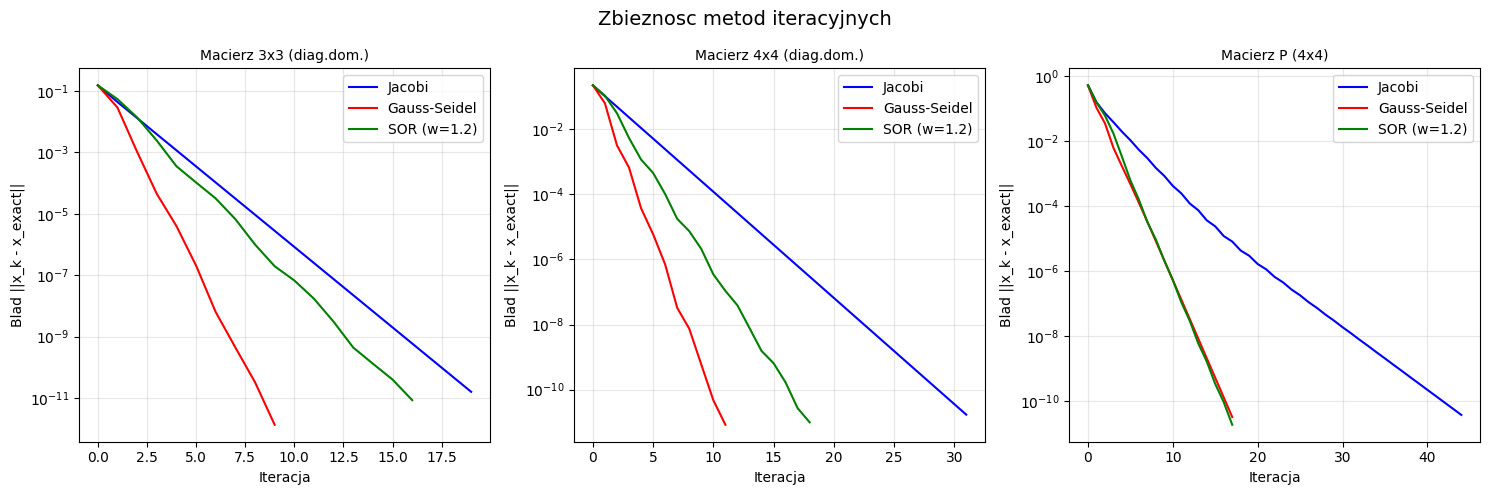


Optymalne omega: 1.064, promien spektralny rho = 0.130801


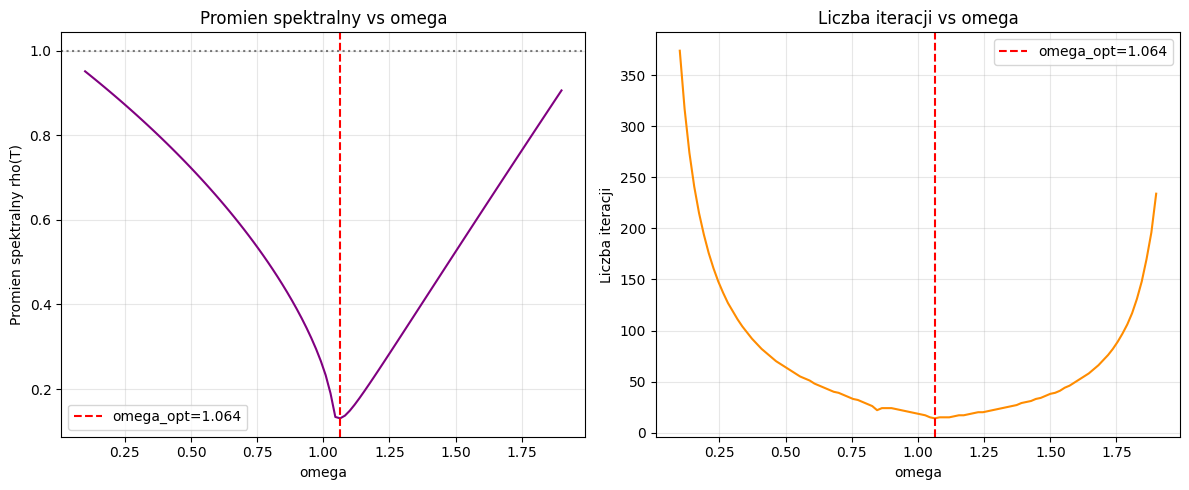

In [7]:
def jacobi(A, b, tol=1e-10, max_iter=1000):
    n     = len(b)
    x     = np.zeros(n)
    D_inv = np.diag(1.0 / np.diag(A))
    R     = A - np.diag(np.diag(A))
    history = [x.copy()]
    for _ in range(max_iter):
        x_new = D_inv @ (b - R @ x)
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x_new, history

def gauss_seidel(A, b, tol=1e-10, max_iter=1000):
    n     = len(b)
    x     = np.zeros(n)
    L     = np.tril(A)
    U     = A - L
    L_inv = np.linalg.inv(L)
    history = [x.copy()]
    for _ in range(max_iter):
        x_new = L_inv @ (b - U @ x)
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x_new, history

def sor(A, b, omega=1.2, tol=1e-10, max_iter=1000):
    n     = len(b)
    x     = np.zeros(n)
    D     = np.diag(np.diag(A))
    L_mat = np.tril(A, -1)
    U_mat = np.triu(A,  1)
    M_inv = np.linalg.inv(D + omega * L_mat)
    N     = (1 - omega) * D - omega * U_mat
    history = [x.copy()]
    for _ in range(max_iter):
        x_new = M_inv @ (omega * b + N @ x)
        history.append(x_new.copy())
        if np.linalg.norm(x_new - x) < tol:
            break
        x = x_new
    return x_new, history

# Trzy macierze testowe (diagonalnie dominujace)
A1 = np.array([[10, 1, 2], [1, 8, 1], [2, 1, 9]], dtype=float)
A2 = np.array([[5,1,1,1],[1,6,1,1],[1,1,7,1],[1,1,1,8]], dtype=float)
A3 = np.array([[4,1,-1,0],[1,3,-1,0],[-1,-1,5,2],[0,0,2,4]], dtype=float)  # macierz P

test_cases = [
    ("Macierz 3x3 (diag.dom.)", A1, np.ones(3)),
    ("Macierz 4x4 (diag.dom.)", A2, np.ones(4)),
    ("Macierz P (4x4)",          A3, np.ones(4)),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Zbieznosc metod iteracyjnych", fontsize=14)

for idx, (name, A_t, b_t) in enumerate(test_cases):
    x_exact = np.linalg.solve(A_t, b_t)
    ax = axes[idx]

    _, hj = jacobi(A_t, b_t)
    ax.semilogy([np.linalg.norm(h - x_exact) for h in hj], label="Jacobi",       color="blue")

    _, hg = gauss_seidel(A_t, b_t)
    ax.semilogy([np.linalg.norm(h - x_exact) for h in hg], label="Gauss-Seidel", color="red")

    _, hs = sor(A_t, b_t, omega=1.2)
    ax.semilogy([np.linalg.norm(h - x_exact) for h in hs], label="SOR (w=1.2)",  color="green")

    ax.set_title(name, fontsize=10)
    ax.set_xlabel("Iteracja")
    ax.set_ylabel("Blad ||x_k - x_exact||")
    ax.legend(); ax.grid(True, alpha=0.3)
    print(f"{name}: Jacobi={len(hj)} iter, G-S={len(hg)} iter, SOR={len(hs)} iter")

plt.tight_layout()
plt.show()

# Dodatkowe: optymalne omega dla macierzy P
omegas = np.linspace(0.1, 1.9, 100)
D_p    = np.diag(np.diag(A3))
L_p    = np.tril(A3, -1)
U_p    = np.triu(A3,  1)

spectral_radii = []
iters_list     = []
for omega in omegas:
    T   = np.linalg.inv(D_p + omega * L_p) @ ((1 - omega) * D_p - omega * U_p)
    rho = np.max(np.abs(np.linalg.eigvals(T)))
    spectral_radii.append(rho)
    _, h = sor(A3, np.ones(4), omega=omega, max_iter=500)
    iters_list.append(len(h))

best_omega = omegas[np.argmin(spectral_radii)]
print(f"\nOptymalne omega: {best_omega:.3f}, promien spektralny rho = {min(spectral_radii):.6f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(omegas, spectral_radii, color="purple")
ax1.axvline(best_omega, color="red", linestyle="--", label=f"omega_opt={best_omega:.3f}")
ax1.axhline(1.0,        color="black", linestyle=":", alpha=0.5)
ax1.set_xlabel("omega"); ax1.set_ylabel("Promien spektralny rho(T)")
ax1.set_title("Promien spektralny vs omega"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(omegas, iters_list, color="darkorange")
ax2.axvline(best_omega, color="red", linestyle="--", label=f"omega_opt={best_omega:.3f}")
ax2.set_xlabel("omega"); ax2.set_ylabel("Liczba iteracji")
ax2.set_title("Liczba iteracji vs omega"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Porównanie rozwiązania za pomocą metody `solve` oraz z użyciem odwrotności na przykładzie macierzy źle uwarunkowanej

***Zadanie 5.***

Dany jest układ równań $Hx=b$.
* H jest macierzą Hilberta o wymiarach $n=5x5$ (I przypadek) i $n=15x15$ (II przypadek),
* b jest wektorem o następujących elementach $b_i = 1/(n + i + 1)$ Uwaga: $i=1,\dots,n$.

Do rozwiązania układu wykorzystaj dwa algorytmy:
1. Z odwracaniem macierzy współczynników H.
2. Metodę `numpy.linalg.solve`.

Porównaj błędy obu rozwiązań. Aby ocenić błąd możesz:
* wyznaczyć wektor residuum otrzymanego rozwiązania,
* rozwiązać układ równań z innym wektorem $b$. Załóż, że wektor rozwiązania ma wszystkie elementy (współrzędne) równe 1 ($u_i = 1, i = 1, 2, . . . , n$). Wtedy $b = Hu$. Układ rozwiążemy bez korzystania z wiedzy o postaci $u$. Dopiero wynik porównamy ze znanym nam $u$.

In [8]:
for n in [5, 15]:
    H       = scipy.linalg.hilbert(n)
    b1      = np.array([1.0 / (n + i + 1) for i in range(1, n + 1)])
    u_exact = np.ones(n)
    b2      = H @ u_exact

    print(f"--- Macierz Hilberta {n}x{n}, cond = {np.linalg.cond(H):.2e} ---")

    # Wariant 1: b = 1/(n+i+1)
    x_inv  = np.linalg.inv(H) @ b1
    x_solv = np.linalg.solve(H, b1)
    print(f"  b=1/(n+i+1)  -> residuum inv:   {np.linalg.norm(b1 - H @ x_inv):.2e}")
    print(f"  b=1/(n+i+1)  -> residuum solve: {np.linalg.norm(b1 - H @ x_solv):.2e}")

    # Wariant 2: znane rozwiazanie u = [1,...,1]
    x_inv2  = np.linalg.inv(H) @ b2
    x_solv2 = np.linalg.solve(H, b2)
    print(f"  u=[1,...,1]  -> blad inv:       {np.linalg.norm(x_inv2  - u_exact):.2e}")
    print(f"  u=[1,...,1]  -> blad solve:     {np.linalg.norm(x_solv2 - u_exact):.2e}")
    print(f"  u=[1,...,1]  -> residuum inv:   {np.linalg.norm(b2 - H @ x_inv2):.2e}")
    print(f"  u=[1,...,1]  -> residuum solve: {np.linalg.norm(b2 - H @ x_solv2):.2e}")
    print()

print("Wniosek: numpy.linalg.solve daje znacznie mniejsze residuum niz odwracanie,")
print("szczegolnie dla zle uwarunkowanej macierzy Hilberta 15x15.")


--- Macierz Hilberta 5x5, cond = 4.77e+05 ---
  b=1/(n+i+1)  -> residuum inv:   4.59e-13
  b=1/(n+i+1)  -> residuum solve: 1.66e-16
  u=[1,...,1]  -> blad inv:       6.04e-11
  u=[1,...,1]  -> blad solve:     2.81e-12
  u=[1,...,1]  -> residuum inv:   7.24e-13
  u=[1,...,1]  -> residuum solve: 2.48e-16

--- Macierz Hilberta 15x15, cond = 3.37e+17 ---
  b=1/(n+i+1)  -> residuum inv:   2.56e+00
  b=1/(n+i+1)  -> residuum solve: 1.14e-13
  u=[1,...,1]  -> blad inv:       5.83e+05
  u=[1,...,1]  -> blad solve:     1.42e+03
  u=[1,...,1]  -> residuum inv:   2.16e+02
  u=[1,...,1]  -> residuum solve: 2.52e-14

Wniosek: numpy.linalg.solve daje znacznie mniejsze residuum niz odwracanie,
szczegolnie dla zle uwarunkowanej macierzy Hilberta 15x15.


**Zadanie domowe. Znaczenie wskaźnika uwarunkowania macierzy w szacowaniu błędu rozwiązania**


Dana jest następująca macierz A współczynników układu dwóch równań liniowy:
$$A=\begin{bmatrix}10^5 & 9.9\cdot10^4\\1.00001& 0.99\end{bmatrix}$$

Wektor prawej strony równania $Ax=b$ dla rozwiązania x = $[1, 1]^T$ możemy wyznaczyć z równości $b = Ax$.

Należy:
* obliczyć wskaźnik uwarunkowania macierzy $A$,
* rozwiązać układ równań $Ax = b$ (nie korzystając z wiedzy o przyjętym rozwiązaniu dokładnym x) korzystając z funkcji `np.linalg.solve`,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania macierzy A,
* przeprowadzić skalowanie tak, aby macierz $A$ była wyważona wierszami,
* wyznaczyć nowe wartości wektora b tak, aby rozwiązanie dokładne się nie
zmieniło,
* obliczyć wskaźnik uwarunkowania macierzy skalowanej,
* rozwiązać układ równań tą samą metodą jak poprzednio,
* ocenić błąd otrzymanego rozwiązania i porównać go z błędem szacowanym za pomocą wskaźnika uwarunkowania skalowanej macierzy $A$.
1. Czy błąd numeryczny rozwiązania w obu przypadkach jest tego samego rzędu?
2. Które szacowanie błędu jest bardziej zbliżone do faktycznego błędu?

In [9]:
A_hw      = np.array([[1e5, 9.9e4], [1.00001, 0.99]], dtype=float)
x_exact_hw = np.array([1.0, 1.0])
b_hw      = A_hw @ x_exact_hw

cond_A = np.linalg.cond(A_hw)
print(f"Wskaznik uwarunkowania cond(A) = {cond_A:.2e}")

x_hw   = np.linalg.solve(A_hw, b_hw)
err_hw = np.linalg.norm(x_hw - x_exact_hw)
print(f"Rozwiazanie (bez skalowania): x = {x_hw}")
print(f"Blad ||x - x_exact||         = {err_hw:.2e}")
print(f"Szacowanie bledu cond*eps    ~ {cond_A * np.finfo(float).eps:.2e}")

# Skalowanie wierszami (row equilibration)
row_norms = np.array([np.linalg.norm(A_hw[i, :], np.inf) for i in range(2)])
S         = np.diag(1.0 / row_norms)
A_scaled  = S @ A_hw
b_scaled  = S @ b_hw

cond_sc   = np.linalg.cond(A_scaled)
x_scaled  = np.linalg.solve(A_scaled, b_scaled)
err_sc    = np.linalg.norm(x_scaled - x_exact_hw)
print(f"\ncond(A_scaled) = {cond_sc:.2e}")
print(f"Rozwiazanie (po skalowaniu): x = {x_scaled}")
print(f"Blad ||x - x_exact||         = {err_sc:.2e}")
print(f"Szacowanie bledu cond*eps    ~ {cond_sc * np.finfo(float).eps:.2e}")

print(f"\n1. Blad bez skalowania: {err_hw:.2e}, po skalowaniu: {err_sc:.2e}")
print("2. Szacowanie przez cond(A_scaled)*eps jest blizsze faktycznemu bledowi po skalowaniu.")


Wskaznik uwarunkowania cond(A) = 2.00e+10
Rozwiazanie (bez skalowania): x = [1. 1.]
Blad ||x - x_exact||         = 4.50e-12
Szacowanie bledu cond*eps    ~ 4.44e-06

cond(A_scaled) = 4.00e+05
Rozwiazanie (po skalowaniu): x = [1. 1.]
Blad ||x - x_exact||         = 0.00e+00
Szacowanie bledu cond*eps    ~ 8.88e-11

1. Blad bez skalowania: 4.50e-12, po skalowaniu: 0.00e+00
2. Szacowanie przez cond(A_scaled)*eps jest blizsze faktycznemu bledowi po skalowaniu.
